In [63]:
import pandas as pd
import os

In [64]:
# load result csv files from the result_data folder
results = pd.read_csv("../result_data/skellam_fusion_test_predictions.csv")


In [65]:
# create new column: true_result, which shows whether HG or AG is greater
# thus: if HG > AG, true_result = 1
# if HG < AG, true_result = -1
# if HG == AG, true_result = 0
results['true_result'] = results.apply(lambda row: 1 if row['HG'] > row['AG'] else (-1 if row['HG'] < row['AG'] else 0), axis=1)

# create new column: predicted_result, which shows whether lambda_home or lambda_away is greater
# thus: if lambda_home > lambda_away, predicted_result = 1
# if lambda_home < lambda_away, predicted_result = -1
# draw is declared, if the difference between lambda_home and lambda_away is less than xx
results['predicted_result'] = results.apply(lambda row: 1 if row['lambda_home'] > row['lambda_away'] + 0.01 else (-1 if row['lambda_home'] < row['lambda_away'] - 0.01 else 0), axis=1)


In [66]:
# calculate accuracy of the predictions
accuracy = (results['true_result'] == results['predicted_result']).mean()
accuracy

np.float64(0.5808080808080808)

In [67]:
results

,game_id,HG,AG,lambda_home,lambda_away,expected_goal_diff,true_result,predicted_result
0,20250815_GIR_RAY,1.0,3.0,0.856530,1.117731,-0.261201,-1,-1
1,20250815_LIV_BOU,4.0,2.0,2.102000,1.252038,0.849962,1,1
2,20250815_REN_OM,1.0,0.0,0.751355,1.067201,-0.315846,1,-1
3,20250816_ALA_LEV,2.0,1.0,1.277018,1.216653,0.060365,1,1
4,20250816_ASM_HAC,3.0,1.0,1.115508,1.196009,-0.080501,1,-1
...,...,...,...,...,...,...,...,...
985,20260426_VIL_CEL,2.0,1.0,1.170335,1.155047,0.015288,1,1
986,20260427_CAG_ATA,3.0,2.0,1.206602,1.170967,0.035635,1,1
987,20260427_ESP_LEV,0.0,0.0,0.851294,1.119447,-0.268153,0,-1
988,20260427_LAZ_UDI,3.0,3.0,1.172385,1.166013,0.006372,0,0


Text(50.722222222222214, 0.5, 'True')

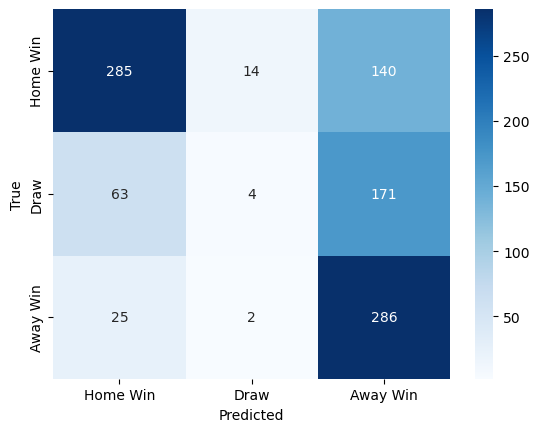

In [71]:
# create confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(results['true_result'], results['predicted_result'], labels=[1, 0, -1])

# display better readable confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(results['true_result'], results['predicted_result'], labels=[1, 0, -1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Home Win', 'Draw', 'Away Win'], yticklabels=['Home Win', 'Draw', 'Away Win'])
plt.xlabel('Predicted')
plt.ylabel('True')

In [69]:
# calculate further metrics: MAE, RMSE, MAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_home = mean_absolute_error(results['HG'], results['lambda_home'])
mae_away = mean_absolute_error(results['AG'], results['lambda_away'])



mape_home = (abs(results['HG'] - results['lambda_home']) / results['HG']).mean()
mape_away = (abs(results['AG'] - results['lambda_away']) / results['AG']).mean()

# print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"MAE Home: {mae_home:.4f}")
print(f"MAE Away: {mae_away:.4f}")

print(f"MAPE Home: {mape_home:.4f}")
print(f"MAPE Away: {mape_away:.4f}")    

Accuracy: 0.5808
MAE Home: 0.8529
MAE Away: 0.9046
MAPE Home: inf
MAPE Away: inf
